# Initial Exploratory Data Analysis — IEEE-CIS Fraud Detection Dataset

## Project Context

This notebook is part of the DDSC611 Machine Learning Operations final project.

The selected dataset is the **IEEE-CIS Fraud Detection** dataset. The task is a binary classification problem where the model predicts whether an online transaction is fraudulent using the target column **isFraud**.

The purpose of this notebook is to:
- Confirm dataset selection.
- Load and inspect the raw dataset.
- Perform initial exploratory data analysis.
- Analyze target imbalance and missing values.
- Identify important features for future preprocessing.
- Identify potential drift-sensitive features for the monitoring stage.

This notebook is only for EDA and does not contain training or production pipeline logic.

## 1. Import Libraries

The following libraries are used for data loading, numerical analysis, and visualization.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

print("Libraries imported successfully.")


Libraries imported successfully.


# Setup Paths

In [ ]:
BASE_DIR = Path("/content")
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
EDA_OUTPUT_DIR = BASE_DIR / "notebooks" / "eda_outputs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Folders ready.")
print("RAW_DIR:", RAW_DIR)
print("EDA_OUTPUT_DIR:", EDA_OUTPUT_DIR)

Folders ready.
RAW_DIR: /content/data/raw
EDA_OUTPUT_DIR: /content/notebooks/eda_outputs


# Unzip Dataset

In [ ]:
zip_path = BASE_DIR / "ieee-fraud-detection.zip"

if zip_path.exists():
    print("Dataset zip found:", zip_path)
    !unzip -q /content/ieee-fraud-detection.zip -d /content/data/raw/
    print("Dataset extracted successfully.")
else:
    print("Dataset zip was not found at /content/ieee-fraud-detection.zip")
    print("Please upload ieee-fraud-detection.zip to Colab first.")

Dataset zip was not found at /content/ieee-fraud-detection.zip
Please upload ieee-fraud-detection.zip to Colab first.


# Check Extracted Files

In [ ]:
print("Files inside data/raw:")

for file in RAW_DIR.iterdir():
    print(file.name)

Files inside data/raw:


## 2. Load the Main Transaction Dataset

The IEEE-CIS dataset is split into transaction and identity files.  
For the initial EDA, the main file used is **train_transaction.csv** because it contains the target variable **isFraud** and the main transaction-level features.

The identity file can be merged later using **TransactionID**, but this notebook focuses first on the core transaction data to keep the initial analysis clear and efficient.

In [ ]:
!rm -rf /content/data/raw/*
!mkdir -p /content/data/raw
!unzip -q /content/ieee-fraud-detection.zip -d /content/data/raw

In [ ]:
!ls /content/data/raw

sample_submission.csv  test_transaction.csv  train_transaction.csv
test_identity.csv      train_identity.csv


In [ ]:
RAW_DIR = Path("/content/data/raw")
transaction_path = RAW_DIR / "train_transaction.csv"

df = pd.read_csv(transaction_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,...,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.0,0.0,0.0,0.0,0.0,10.0,0.0,4.0,0.0,0.0,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Dataset Overview

This section checks the dataset size, column types, target column, and unique transaction identifiers.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Target column:", "isFraud")
print("Unique Transaction IDs:", df["TransactionID"].nunique())

df.info()

Number of rows: 590540
Number of columns: 394
Target column: isFraud
Unique Transaction IDs: 590540
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


### Dataset Structure Insight

The dataset contains 590,540 transactions and 394 features, making it a high-dimensional dataset.  

Each transaction has a unique **TransactionID**, meaning there are no duplicate records.  

The majority of features are numerical (376), while only a small subset (14) are categorical. Many numerical features are anonymized (V1–V339), which indicates that feature interpretation will be limited and model-based approaches will be important.  

This structure makes the dataset suitable for real-world fraud detection tasks and aligns well with MLOps requirements such as preprocessing pipelines and monitoring.

# Display Column Groups

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)

Number of numerical columns: 380
Number of categorical columns: 14

Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


### Feature Type Insight

The dataset is dominated by numerical features, many of which are anonymized (V1–V339). These features are likely engineered representations of original transaction data.

The categorical features are limited but important, including product codes, card information, and email domains. These interpretable features are especially useful for both exploratory analysis and future drift monitoring.

# Descriptive Statistics

In [ ]:
df.describe(include="all").T.head(40)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,NaN,NaN,NaN,3282269.5,170474.35832,2987000.0,3134634.75,3282269.5,3429904.25,3577539.0
isFraud,590540.0,NaN,NaN,NaN,0.03499,0.183755,0.0,0.0,0.0,0.0,1.0
TransactionDT,590540.0,NaN,NaN,NaN,7372311.310116,4617223.64654,86400.0,3027057.75,7306527.5,11246620.0,15811131.0
TransactionAmt,590540.0,NaN,NaN,NaN,135.027176,239.162522,0.251,43.321,68.769,125.0,31937.391
ProductCD,590540,5,W,439670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card1,590540.0,NaN,NaN,NaN,9898.734658,4901.170153,1000.0,6019.0,9678.0,14184.0,18396.0
card2,581607.0,NaN,NaN,NaN,362.555488,157.793246,100.0,214.0,361.0,512.0,600.0
card3,588975.0,NaN,NaN,NaN,153.194925,11.336444,100.0,150.0,150.0,150.0,231.0
card4,588963,4,visa,384767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card5,586281.0,NaN,NaN,NaN,199.278897,41.244453,100.0,166.0,226.0,226.0,237.0


### Descriptive Statistics Insight

The descriptive statistics provide an initial understanding of the dataset's structure and feature behavior.

1. Target Variable (isFraud)  
- The mean value of isFraud is approximately 0.035, indicating that only about 3.5% of transactions are fraudulent.  
- This confirms that the dataset is highly imbalanced, which is a critical challenge for fraud detection models.

2. Transaction Amount (TransactionAmt)  
- The transaction amount shows a strong skew, with a mean of around 135 and a maximum value exceeding 31,000.  
- This indicates the presence of extreme values (outliers), which may affect model performance and should be handled carefully in preprocessing.

3. Categorical Features  
- The ProductCD feature is dominated by one category (W), showing an imbalanced distribution.  
- Similarly, features like card4 and card6 have dominant categories such as visa and debit.

4. Missing Values  
- Several features have significantly fewer non-null values compared to the total number of rows.  
- For example, dist2 and R_emaildomain have many missing values, indicating that missing data handling will be essential in the preprocessing stage.

5. Feature Distribution  
- Many numerical features (such as C and D features) show wide ranges and high variance.  
- Some features also contain negative values, suggesting that they are transformed or engineered variables rather than raw measurements.

Overall, the dataset is complex, high-dimensional, and contains several challenges such as class imbalance, missing values, and skewed distributions. These characteristics make it suitable for a realistic MLOps pipeline involving preprocessing, modeling, and monitoring.

## Target Variable Distribution

Understanding the distribution of the target variable (`isFraud`) is crucial to identify class imbalance.

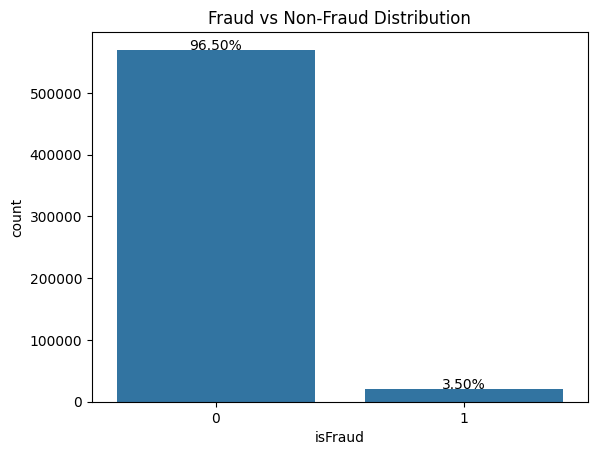

In [ ]:
counts = df["isFraud"].value_counts()
percentages = df["isFraud"].value_counts(normalize=True) * 100

sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")

for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(i, count, f"{pct:.2f}%", ha='center')

plt.show()

## Target Variable Distribution

The dataset is highly imbalanced: ~96.5% non-fraud and ~3.5% fraud.  
This imbalance must be handled during modeling.

### Skewness of Transaction Amount

In [ ]:
skew_val = df["TransactionAmt"].skew()
print(f"Skewness of TransactionAmt: {skew_val:.2f}")

Skewness of TransactionAmt: 14.37


### Transaction Amount Skewness Insight

The skewness of **TransactionAmt** is approximately 14.37, which indicates an extremely right-skewed distribution.

This means that most transactions have relatively small values, while a small number of transactions have very large amounts. These extreme values represent outliers.

This skewness is important because:
- It may negatively affect model performance if not handled properly.
- It suggests that transformations such as log scaling may be useful during preprocessing.
- It makes **TransactionAmt** a strong candidate for drift monitoring, as changes in spending behavior over time could significantly impact its distribution.

## 4. Target Variable Analysis

The target variable is **isFraud**:
- **0** means non-fraudulent transaction.
- **1** means fraudulent transaction.

This section checks class imbalance, which is one of the key challenges of this dataset.

# Target Distribution Table

In [ ]:
target_counts = df["isFraud"].value_counts()
target_percentages = df["isFraud"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentages.values.round(2)
})

target_summary

,Class,Count,Percentage
0,0,569877,96.5
1,1,20663,3.5


### Target Distribution Insight

The target variable **isFraud** is highly imbalanced:

- Non-fraud (0): 96.5%  
- Fraud (1): 3.5%  

This imbalance may bias the model toward the majority class. Therefore, metrics such as precision, recall, F1-score, and ROC-AUC should be used instead of accuracy.

# Target Distribution Plot

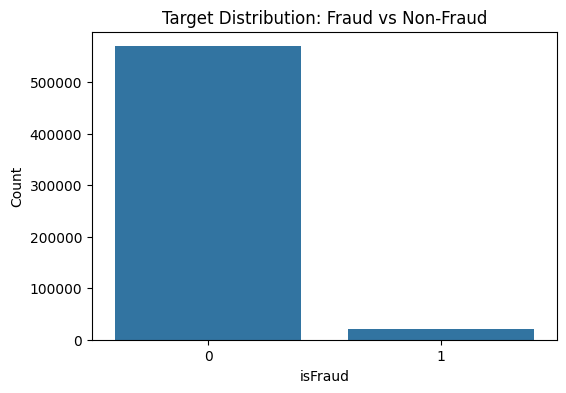

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="isFraud", data=df)
plt.title("Target Distribution: Fraud vs Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

### Target Distribution Insight

The dataset is highly imbalanced, with non-fraud transactions dominating. Fraud cases are very limited, which may affect model performance and requires careful evaluation metrics.

# Fraud Percentage

In [ ]:
fraud_rate = df["isFraud"].mean() * 100
print(f"Fraud rate: {fraud_rate:.2f}%")

Fraud rate: 3.50%


### Fraud Rate Insight

The fraud rate is approximately 3.5%, confirming that fraudulent transactions are rare. This reinforces the presence of class imbalance and highlights the need for careful model evaluation.

## 5. Missing Values Analysis

Missing values are important in this dataset because many transaction and anonymized features contain incomplete data. This directly affects the preprocessing pipeline, where imputation strategies will be required.

# Missing Values Table

In [ ]:
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100

missing_df = pd.DataFrame({
    "Feature": missing_percent.index,
    "Missing_Percentage": missing_percent.values
})

missing_df.head(30)

,Feature,Missing_Percentage
0,dist2,93.628374
1,D7,93.409930
2,D13,89.509263
3,D14,89.469469
4,D12,89.041047
5,D6,87.606767
6,D8,87.312290
7,D9,87.312290
8,V162,86.123717
9,V142,86.123717


# Missing Values Plot

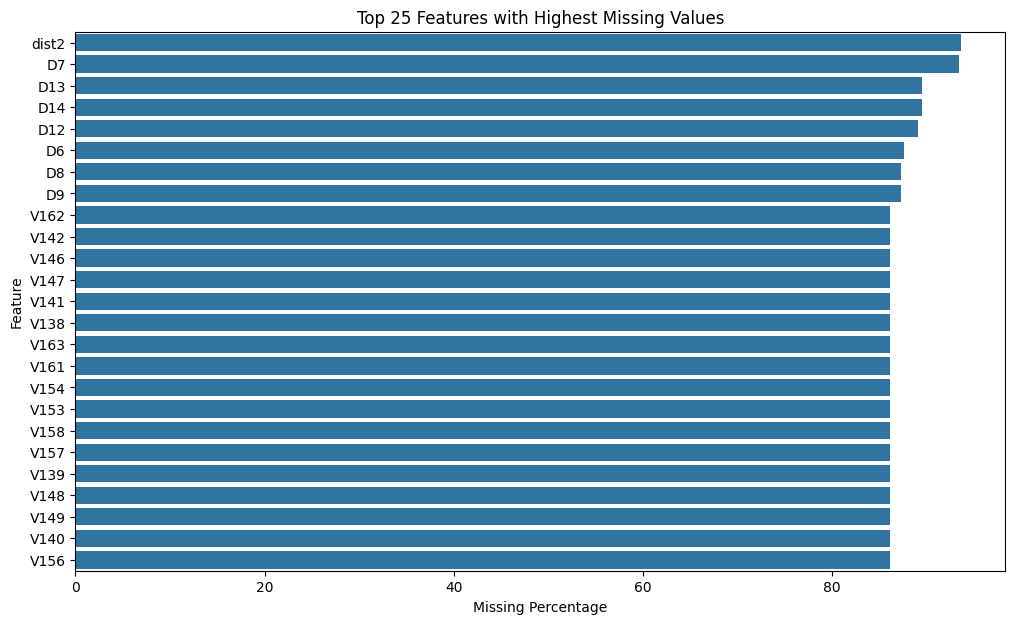

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=missing_df.head(25),
    x="Missing_Percentage",
    y="Feature"
)
plt.title("Top 25 Features with Highest Missing Values")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.show()

# Missing Value Groups

In [ ]:
missing_groups = pd.cut(
    missing_percent,
    bins=[0, 10, 30, 50, 70, 100],
    labels=["0-10%", "10-30%", "30-50%", "50-70%", "70-100%"],
    include_lowest=True
)

missing_group_summary = missing_groups.value_counts().sort_index()
missing_group_summary

,count
0-10%,112
10-30%,90
30-50%,18
50-70%,6
70-100%,168


# Plot Missing Groups

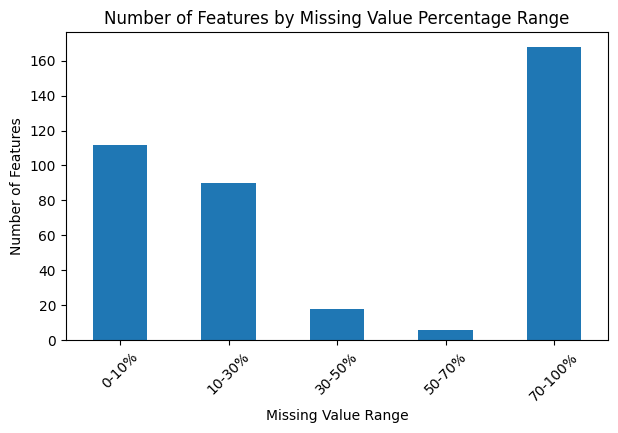

In [ ]:
plt.figure(figsize=(7, 4))
missing_group_summary.plot(kind="bar")
plt.title("Number of Features by Missing Value Percentage Range")
plt.xlabel("Missing Value Range")
plt.ylabel("Number of Features")
plt.xticks(rotation=45)
plt.show()

### Missing Values Insight

Many features contain a high percentage of missing values, with some exceeding 90%.  

Key observations:
- Features like `dist2` and `D7` have more than 90% missing values.
- Many anonymized features (V-series) have around 86% missing values.
- This suggests that missing values are not random and may follow specific patterns.

These characteristics indicate that the dataset is highly sparse, and missing values will need careful handling in the preprocessing stage. In addition, missingness itself may carry useful information for fraud detection.

## 6. Important Transaction Features

The following features are especially useful for initial analysis:

- **TransactionDT**: relative time offset of the transaction.
- **TransactionAmt**: transaction amount.
- **ProductCD**: product code.
- **card1** to **card6**: card-related features.
- **addr1**, **addr2**: address-related features.
- **P_emaildomain**, **R_emaildomain**: purchaser and recipient email domains.

These features are useful because they are interpretable compared to anonymized columns and can also be potential sources of drift.

# Feature Availability Check

In [ ]:
important_features = [
    "TransactionID",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain",
    "isFraud"
]

existing_important_features = [col for col in important_features if col in df.columns]

print("Available important features:")
print(existing_important_features)

df[existing_important_features].head()

Available important features:
['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'isFraud']


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,P_emaildomain,R_emaildomain,isFraud
0,2987000,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,NaN,NaN,0
1,2987001,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,gmail.com,NaN,0
2,2987002,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,outlook.com,NaN,0
3,2987003,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,yahoo.com,NaN,0
4,2987004,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,gmail.com,NaN,0


### Important Features Selection

A subset of interpretable features was selected for analysis, including transaction details, card information, and email domains.

These features are important because:
- They represent real-world transaction attributes (unlike anonymized V features).
- They are easier to interpret and analyze.
- They are strong candidates for detecting data drift over time.

This subset will be used for focused exploratory analysis and drift identification.

## 7. Transaction Amount Analysis

**TransactionAmt** is an important numerical feature because changes in transaction value patterns may indicate customer behavior changes, fraud strategy changes, or seasonal effects.

# Transaction Amount Distribution

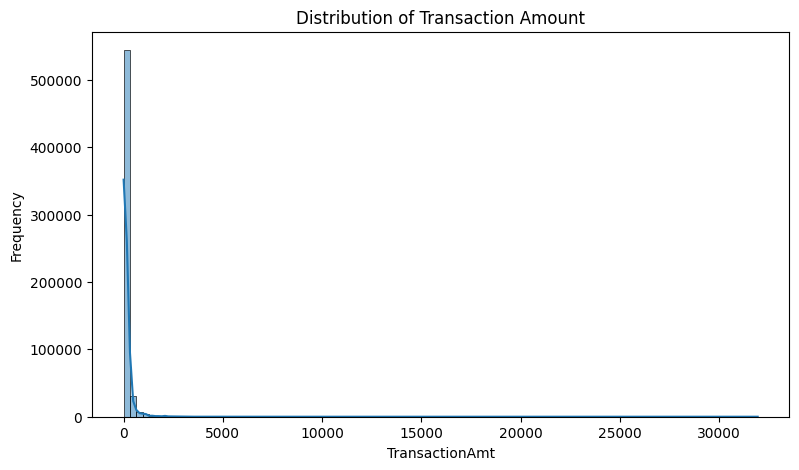

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df["TransactionAmt"], bins=100, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("TransactionAmt")
plt.ylabel("Frequency")
plt.show()

# Transaction Amount by Fraud Class

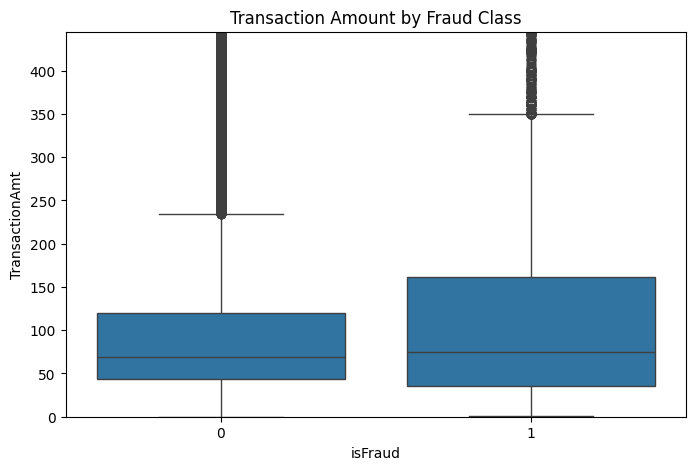

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="isFraud", y="TransactionAmt", data=df)
plt.title("Transaction Amount by Fraud Class")
plt.xlabel("isFraud")
plt.ylabel("TransactionAmt")
plt.ylim(0, df["TransactionAmt"].quantile(0.95))
plt.show()

# Transaction Amount Summary

In [ ]:
df.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


### Transaction Amount Insight

The transaction amount is highly right-skewed, with most transactions having low values and a small number of very large transactions.

Fraudulent transactions tend to have slightly higher amounts on average compared to non-fraud transactions. The median and upper quartiles are also higher for fraud cases.

This suggests that transaction amount may be a useful feature for distinguishing fraudulent behavior. Additionally, the presence of extreme values indicates that outliers should be considered during preprocessing.

## 8. Product Code Analysis

`ProductCD` is a categorical feature representing product type. Product usage distribution may change over time, making it useful for drift monitoring.

# ProductCD Distribution

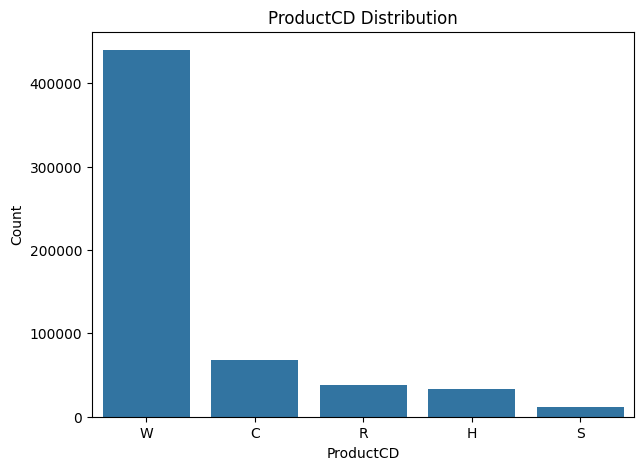

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(
    x="ProductCD",
    data=df,
    order=df["ProductCD"].value_counts().index
)
plt.title("ProductCD Distribution")
plt.xlabel("ProductCD")
plt.ylabel("Count")
plt.show()

# Fraud Rate by ProductCD

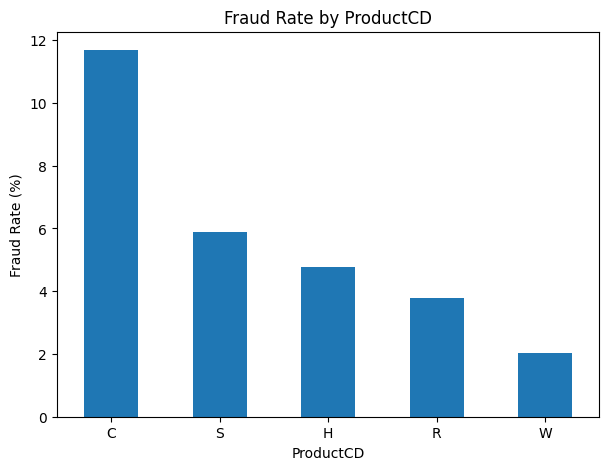

,isFraud
ProductCD,
C,11.687269
S,5.899553
H,4.766231
R,3.782594
W,2.039939


In [ ]:
product_fraud_rate = df.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 5))
product_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by ProductCD")
plt.xlabel("ProductCD")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)
plt.show()

product_fraud_rate

### ProductCD Insight

The **ProductCD** feature shows a highly imbalanced distribution, with category **W** dominating the dataset.

However, fraud rates vary significantly across categories:
- Category **C** has the highest fraud rate (~11.7%)
- Category **W** has the lowest (~2.0%)

This indicates that **ProductCD** is a strong predictive feature and may be useful for distinguishing fraudulent transactions. It is also a good candidate for drift monitoring.

## 9. Card Feature Analysis

Card-related features such as `card4` and `card6` describe payment card properties. These features may drift if customer payment preferences or fraudster behavior changes over time.

# card4 Distribution

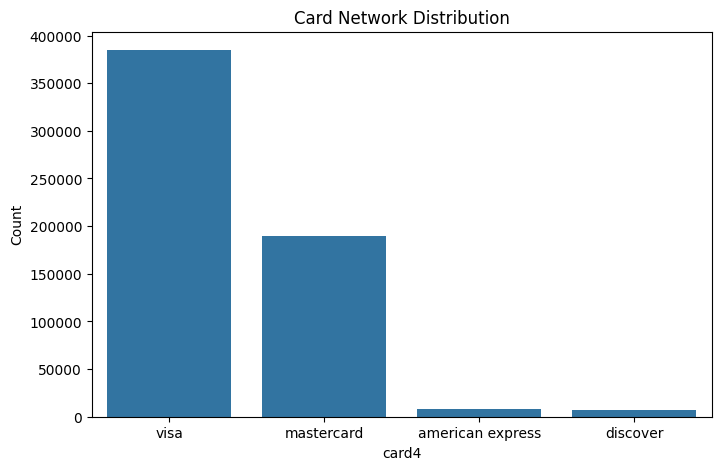

In [ ]:
if "card4" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x="card4",
        data=df,
        order=df["card4"].value_counts().index
    )
    plt.title("Card Network Distribution")
    plt.xlabel("card4")
    plt.ylabel("Count")
    plt.show()

# Fraud Rate by card4

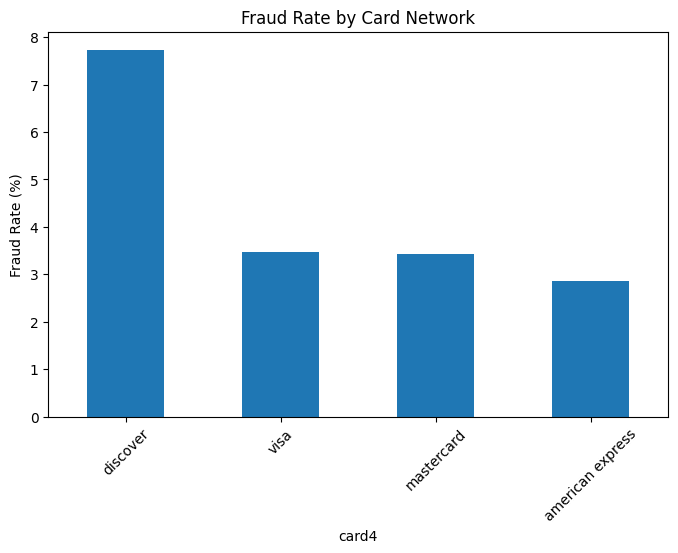

,isFraud
card4,
discover,7.728161
visa,3.475610
mastercard,3.433095
american express,2.869837


In [ ]:
if "card4" in df.columns:
    card4_fraud_rate = df.groupby("card4")["isFraud"].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(8, 5))
    card4_fraud_rate.plot(kind="bar")
    plt.title("Fraud Rate by Card Network")
    plt.xlabel("card4")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=45)
    plt.show()

    display(card4_fraud_rate)

# card6 Distribution


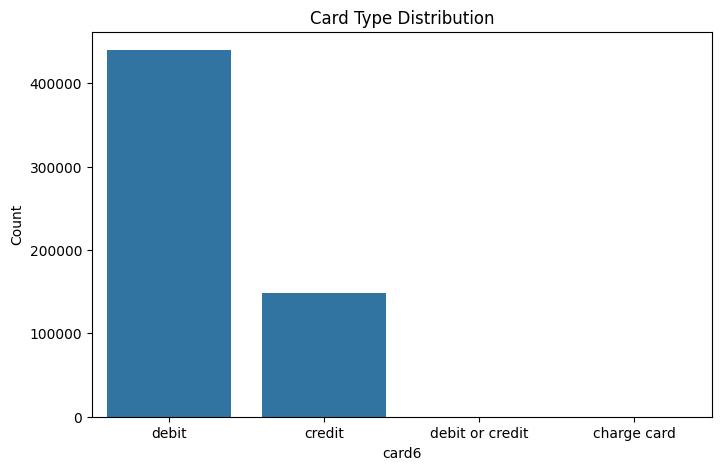

In [ ]:
if "card6" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x="card6",
        data=df,
        order=df["card6"].value_counts().index
    )
    plt.title("Card Type Distribution")
    plt.xlabel("card6")
    plt.ylabel("Count")
    plt.show()

# Fraud Rate by card6

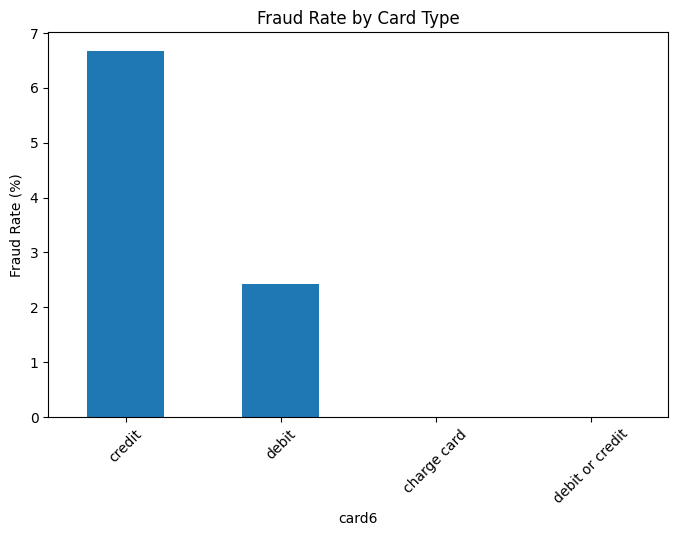

,isFraud
card6,
credit,6.678480
debit,2.426251
charge card,0.000000
debit or credit,0.000000


In [ ]:
if "card6" in df.columns:
    card6_fraud_rate = df.groupby("card6")["isFraud"].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(8, 5))
    card6_fraud_rate.plot(kind="bar")
    plt.title("Fraud Rate by Card Type")
    plt.xlabel("card6")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=45)
    plt.show()

    display(card6_fraud_rate)

### Card Type Insight

The dataset is heavily dominated by debit and credit cards, with debit transactions being the majority.

Fraud rates differ significantly:
- Credit cards show a higher fraud rate (~6.7%)
- Debit cards have a lower fraud rate (~2.4%)

Other categories (e.g., charge card, debit or credit) have extremely low sample sizes and are not statistically reliable for analysis.

This indicates that card type is an important feature for fraud detection and should be considered in modeling and drift monitoring.

## 10. Email Domain Analysis

Email domain features can reflect customer identity and behavioral patterns. They may drift over time if user groups or fraud strategies change.

# Top Purchaser Email Domains

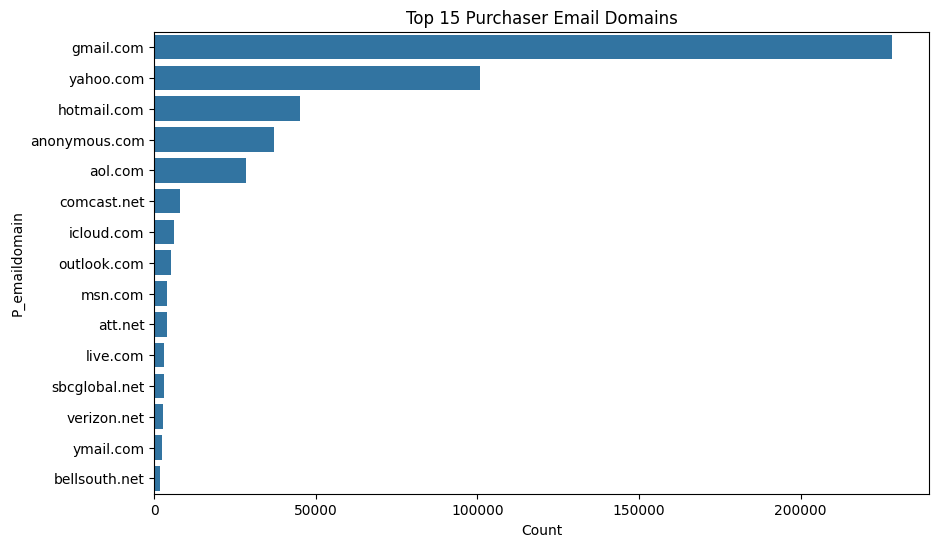

In [ ]:
if "P_emaildomain" in df.columns:
    top_email_domains = df["P_emaildomain"].value_counts().head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_email_domains.values, y=top_email_domains.index)
    plt.title("Top 15 Purchaser Email Domains")
    plt.xlabel("Count")
    plt.ylabel("P_emaildomain")
    plt.show()

# Fraud Rate by Purchaser Email Domain

In [ ]:
if "P_emaildomain" in df.columns:
    email_fraud_rate = (
        df.groupby("P_emaildomain")["isFraud"]
        .agg(["count", "mean"])
        .query("count >= 500")
        .sort_values("mean", ascending=False)
    )

    email_fraud_rate["fraud_rate_percent"] = email_fraud_rate["mean"] * 100
    email_fraud_rate.head(15)
print(email_fraud_rate.head(15))

                count      mean  fraud_rate_percent
P_emaildomain                                      
mail.com          559  0.189624           18.962433
outlook.com      5096  0.094584            9.458399
live.com.mx       749  0.054740            5.473965
hotmail.com     45250  0.052950            5.295028
gmail.com      228355  0.043542            4.354185
icloud.com       6267  0.031434            3.143450
comcast.net      7888  0.031187            3.118661
charter.net       816  0.030637            3.063725
bellsouth.net    1909  0.027763            2.776323
live.com         3041  0.027622            2.762249
anonymous.com   36998  0.023217            2.321747
yahoo.com      100934  0.022757            2.275745
msn.com          4092  0.021994            2.199413
aol.com         28289  0.021811            2.181060
earthlink.net     514  0.021401            2.140078


### Email Domain Fraud Insight

Fraud rates vary significantly across email domains, indicating that this feature carries strong predictive value.

Key observations:
- Some domains show very high fraud rates, such as **mail.com (~19%)** and **outlook.com (~9.4%)**.
- Common providers like **gmail.com (~4.3%)** and **yahoo.com (~2.3%)** have lower fraud rates but dominate the dataset in volume.
- High fraud rates in less frequent domains may indicate suspicious or disposable email usage patterns.

To ensure reliable analysis, only domains with sufficient sample size (≥ 500 transactions) were considered.

Overall, email domain is a valuable feature for fraud detection and may also serve as an indicator of behavioral drift over time.

## 11. Time-Based Analysis Using TransactionDT

`TransactionDT` is not an actual timestamp. It is a relative time offset from a reference datetime.  
However, it still preserves the order of transactions over time.

This makes it very useful for creating a time-based split:
- Earlier transactions = reference set.
- Later transactions = production-like set.

This approach matches real MLOps monitoring, where the model is trained on historical data and monitored on newer production data.

# TransactionDT Distribution

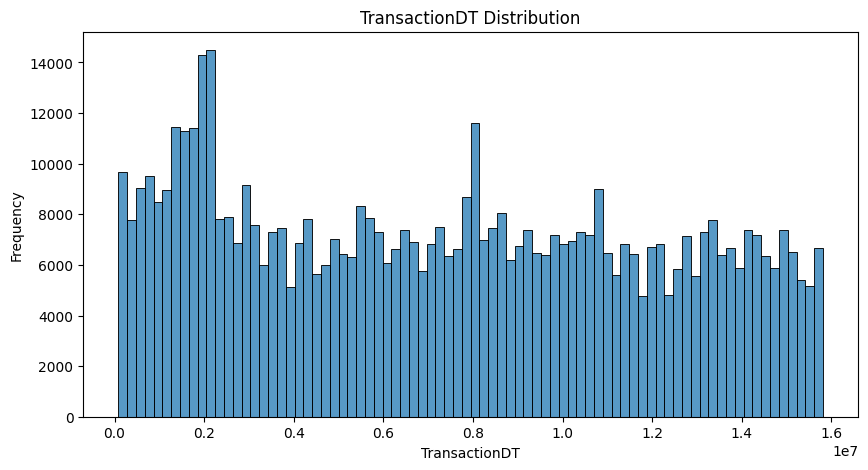

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["TransactionDT"], bins=80)
plt.title("TransactionDT Distribution")
plt.xlabel("TransactionDT")
plt.ylabel("Frequency")
plt.show()

# Fraud Rate Over Time

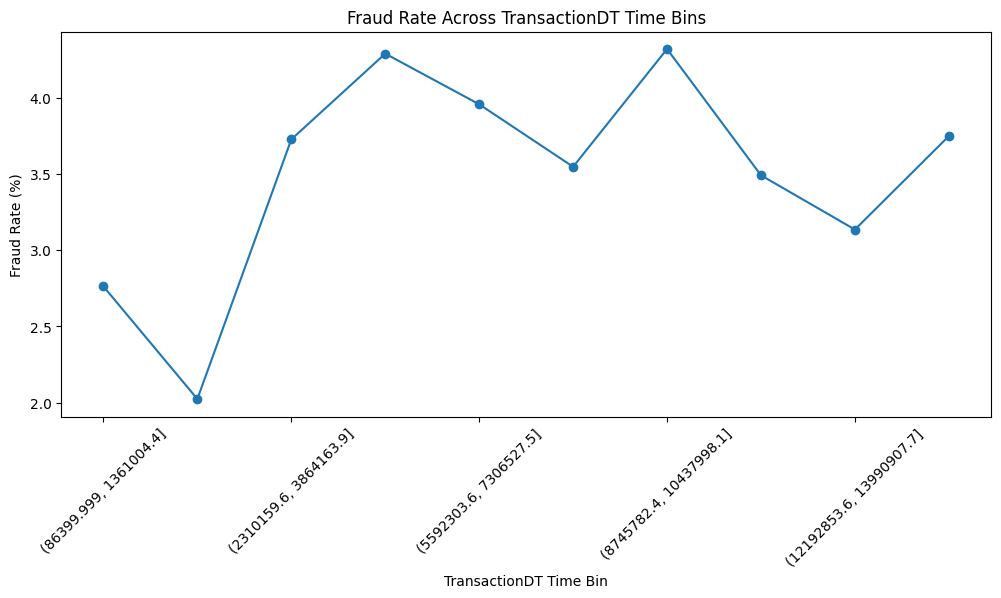

,isFraud
time_bin,
"(86399.999, 1361004.4]",2.761879
"(1361004.4, 2310159.6]",2.023572
"(2310159.6, 3864163.9]",3.725404
"(3864163.9, 5592303.6]",4.287601
"(5592303.6, 7306527.5]",3.955702
"(7306527.5, 8745782.4]",3.545907
"(8745782.4, 10437998.1]",4.318082
"(10437998.1, 12192853.6]",3.490026
"(12192853.6, 13990907.7]",3.134419


In [ ]:
df_time = df.copy()
df_time["time_bin"] = pd.qcut(df_time["TransactionDT"], q=10, duplicates="drop")

fraud_over_time = df_time.groupby("time_bin", observed=False)["isFraud"].mean() * 100

plt.figure(figsize=(12, 5))
fraud_over_time.plot(marker="o")
plt.title("Fraud Rate Across TransactionDT Time Bins")
plt.xlabel("TransactionDT Time Bin")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

fraud_over_time

### Temporal (TransactionDT) Insight

The `TransactionDT` feature represents the time progression of transactions and spans a wide continuous range.

Analysis across time bins shows that fraud rates are not stable over time:
- Fraud rates vary between approximately **2.0% and 4.3%**
- Certain time periods exhibit noticeably higher fraud activity than others

This indicates the presence of **temporal drift**, where the underlying data distribution and fraud patterns change over time.

Such behavior is critical for MLOps systems, as models trained on historical data may become less effective if these temporal patterns shift.

Therefore, time-based validation, monitoring, and potential model retraining strategies will be necessary to maintain model performance.

## Correlation Analysis

To understand relationships between numerical features and detect redundancy or dependencies, we compute the correlation matrix.

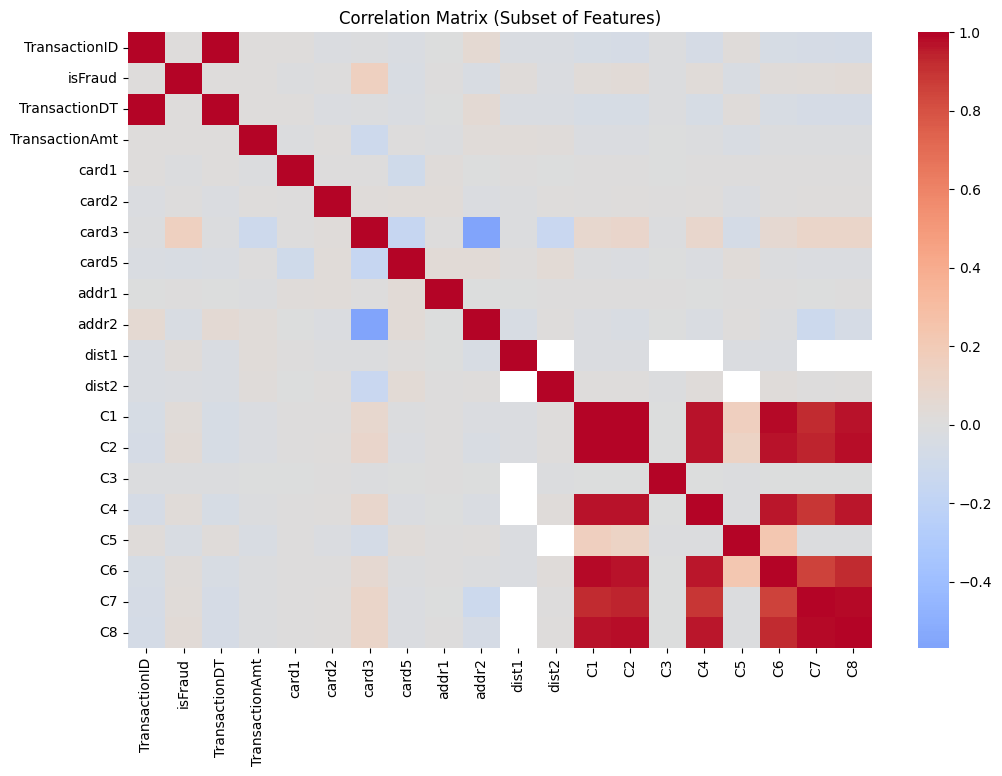

In [ ]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr.iloc[:20, :20], cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Subset of Features)")
plt.show()

## Correlation Analysis

The correlation matrix shows relationships between numerical features.  
Some features (especially C1–C8) are highly correlated, indicating redundancy and potential multicollinearity.

## 12. Reference and Production Split for Drift Analysis

For initial drift investigation, the data is sorted by `TransactionDT` and split as follows:

- First 70% of transactions: reference dataset.
- Last 30% of transactions: production-like dataset.

This split simulates real deployment, where a model trained on past data is monitored on newer incoming data.

# Create Reference and Production Sets

In [ ]:
df_sorted = df.sort_values("TransactionDT").reset_index(drop=True)

split_index = int(len(df_sorted) * 0.70)

reference_df = df_sorted.iloc[:split_index].copy()
production_df = df_sorted.iloc[split_index:].copy()

print("Reference shape:", reference_df.shape)
print("Production shape:", production_df.shape)

print("Reference fraud rate:", round(reference_df["isFraud"].mean() * 100, 2), "%")
print("Production fraud rate:", round(production_df["isFraud"].mean() * 100, 2), "%")

Reference shape: (413378, 394)
Production shape: (177162, 394)
Reference fraud rate: 3.52 %
Production fraud rate: 3.46 %


## 13. Initial Drift Feature Comparison

The following features are selected as initial drift candidates:

- TransactionAmt
- ProductCD
- card4
- card6
- addr1
- P_emaildomain

These features were selected because they represent transaction value, product type, card behavior, regional information, and customer identity patterns.

# Define Drift Candidates

In [ ]:
drift_features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",
    "addr1",
    "P_emaildomain"
]

drift_features = [col for col in drift_features if col in df.columns]

print("Selected drift candidate features:")
print(drift_features)

Selected drift candidate features:
['TransactionAmt', 'ProductCD', 'card4', 'card6', 'addr1', 'P_emaildomain']


# TransactionAmt Reference vs Production

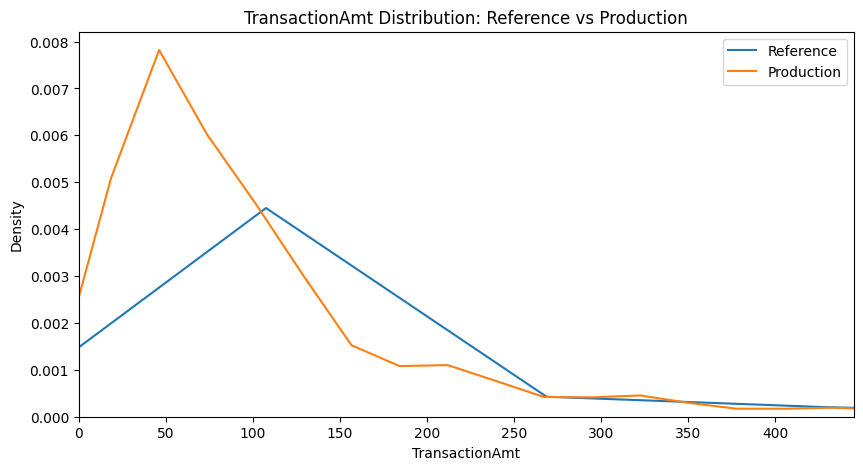

In [ ]:
if "TransactionAmt" in drift_features:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(reference_df["TransactionAmt"], label="Reference")
    sns.kdeplot(production_df["TransactionAmt"], label="Production")
    plt.xlim(0, df["TransactionAmt"].quantile(0.95))
    plt.title("TransactionAmt Distribution: Reference vs Production")
    plt.xlabel("TransactionAmt")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Categorical Comparison Function

In [ ]:
def compare_categorical_distribution(feature, top_n=10):
    ref_dist = reference_df[feature].value_counts(normalize=True).head(top_n) * 100
    prod_dist = production_df[feature].value_counts(normalize=True).reindex(ref_dist.index) * 100

    compare_df = pd.DataFrame({
        "Reference_%": ref_dist,
        "Production_%": prod_dist
    }).fillna(0)

    compare_df.plot(kind="bar", figsize=(10, 5))
    plt.title(f"{feature} Distribution: Reference vs Production")
    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.show()

    return compare_df

# Compare ProductCD

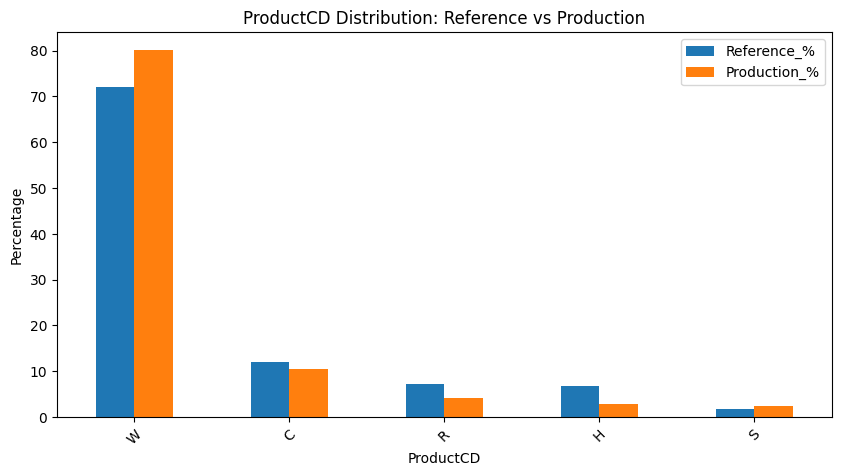

In [ ]:
if "ProductCD" in drift_features:
    productcd_comparison = compare_categorical_distribution("ProductCD")
    productcd_comparison

# Compare card4

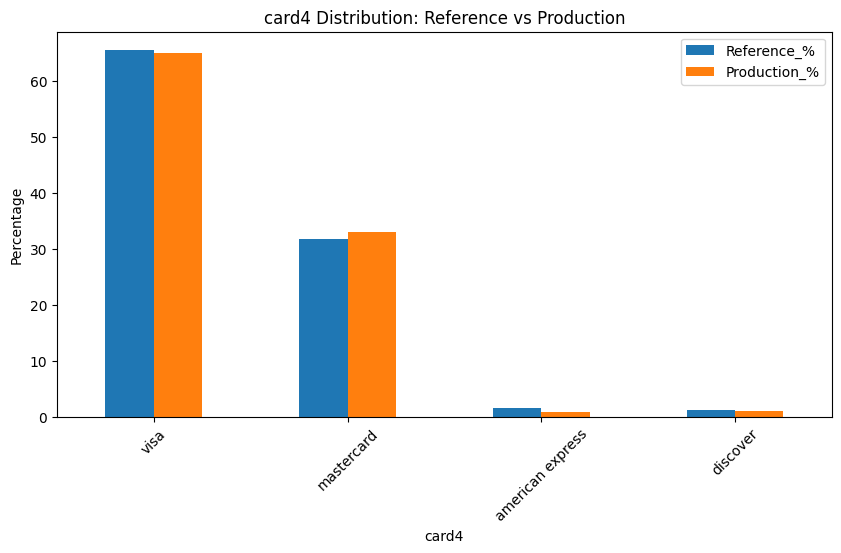

In [ ]:
if "card4" in drift_features:
    card4_comparison = compare_categorical_distribution("card4")
    card4_comparison

# Compare card6

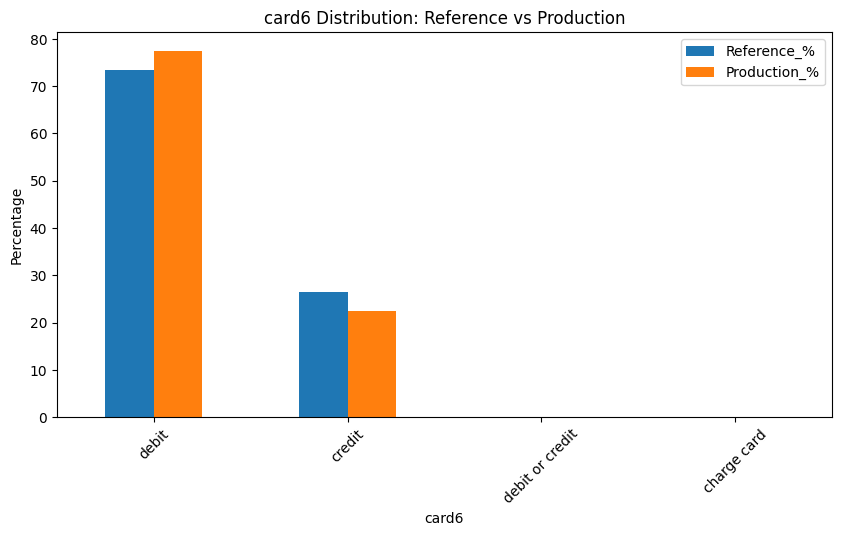

In [ ]:
if "card6" in drift_features:
    card6_comparison = compare_categorical_distribution("card6")
    card6_comparison

# Compare P_emaildomain

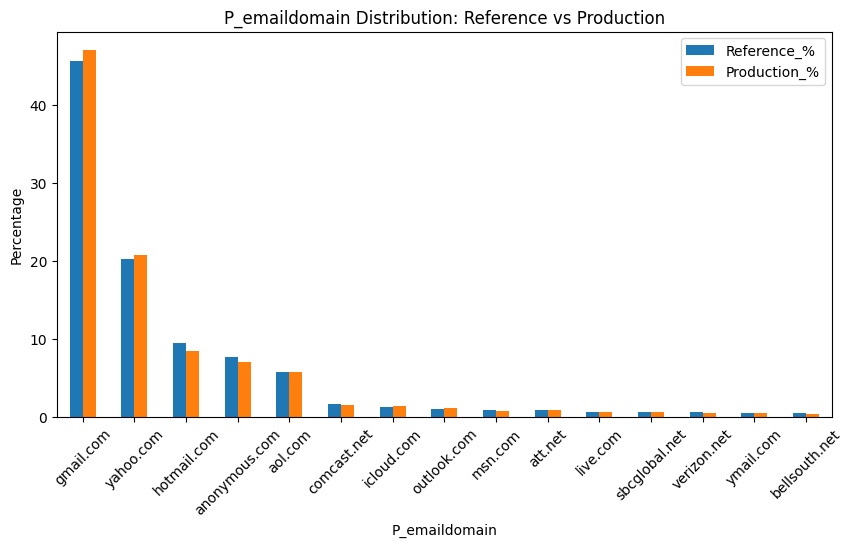

In [ ]:
if "P_emaildomain" in drift_features:
    email_comparison = compare_categorical_distribution("P_emaildomain", top_n=15)
    email_comparison

### Categorical Feature Drift Insight

Several categorical features show noticeable distribution shifts between the reference and production datasets.

**ProductCD:**
- Product W increased in production data
- Other categories (C, R, H) slightly decreased  
→ Indicates a shift in product usage behavior

**Card Network (card4):**
- Slight increase in Mastercard usage
- Slight decrease in Visa proportion
- Minor changes in American Express and Discover  
→ Indicates mild drift in payment network preferences

**Card Type (card6):**
- Debit transactions increased in production
- Credit transactions decreased
- Other categories (charge card, debit or credit) are negligible  
→ Suggests a shift toward debit-based transactions over time

**Email Domain (P_emaildomain):**
- Major domains (gmail.com, yahoo.com) remain dominant
- Small but noticeable variations across domains  
→ Indicates stable overall structure with minor distribution shifts

**Overall Insight:**
Categorical features exhibit moderate drift, reflecting changes in user behavior and transaction patterns over time. These shifts should be monitored, as they may impact model performance in production.

## 14. Drift Feature Candidate Summary

This table summarizes the main candidate features for future drift monitoring.

# Drift Summary Table

In [ ]:
drift_summary = pd.DataFrame({
    "Feature": [
        "TransactionDT",
        "TransactionAmt",
        "ProductCD",
        "card4",
        "card6",
        "addr1",
        "P_emaildomain"
    ],
    "Feature_Type": [
        "Time-based",
        "Numerical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numerical/Categorical-like",
        "Categorical"
    ],
    "Why_It_Can_Drift": [
        "Captures temporal patterns; transaction behavior evolves over time.",
        "Transaction values may shift due to changes in customer spending behavior and transaction patterns over time.",
        "Product usage distribution may change between historical and production periods.",
        "Card network preferences may change over time.",
        "Payment method usage (debit vs credit) may shift with customer behavior.",
        "Geographic transaction patterns may vary across time periods.",
        "Email domain usage patterns may change over time, reflecting shifts in customer behavior."
    ],
    "Recommended_Use_In_Monitoring": [
        "Use for time-based reference/production data splitting.",
        "Monitor numerical distribution drift.",
        "Monitor categorical distribution drift.",
        "Monitor categorical distribution drift.",
        "Monitor categorical distribution drift.",
        "Monitor location-related distribution drift.",
        "Monitor customer identity-related distribution drift."
    ]
})

drift_summary

,Feature,Feature_Type,Why_It_Can_Drift,Recommended_Use_In_Monitoring
0,TransactionDT,Time-based,Captures temporal patterns; transaction behavi...,Use for time-based reference/production data s...
1,TransactionAmt,Numerical,Transaction values may shift due to changes in...,Monitor numerical distribution drift.
2,ProductCD,Categorical,Product usage distribution may change between ...,Monitor categorical distribution drift.
3,card4,Categorical,Card network preferences may change over time.,Monitor categorical distribution drift.
4,card6,Categorical,Payment method usage (debit vs credit) may shi...,Monitor categorical distribution drift.
5,addr1,Numerical/Categorical-like,Geographic transaction patterns may vary acros...,Monitor location-related distribution drift.
6,P_emaildomain,Categorical,Email domain usage patterns may change over ti...,Monitor customer identity-related distribution...


## 15. Save EDA Output Summaries

The following summary files are saved for documentation and later reference:
- Target distribution summary.
- Missing values summary.
- Drift feature candidates.

In [ ]:
target_summary.to_csv(EDA_OUTPUT_DIR / "target_distribution_summary.csv", index=False)
missing_df.to_csv(EDA_OUTPUT_DIR / "missing_values_summary.csv", index=False)
drift_summary.to_csv(EDA_OUTPUT_DIR / "drift_feature_candidates.csv", index=False)

print("EDA summary files saved successfully.")
print("Saved files:")
for file in EDA_OUTPUT_DIR.iterdir():
    print(file.name)

EDA summary files saved successfully.
Saved files:
missing_values_summary.csv
target_distribution_summary.csv
drift_feature_candidates.csv


## Final EDA Conclusion

The IEEE-CIS Fraud Detection dataset is a large, high-dimensional dataset suitable for real-world fraud detection tasks. It contains over 590,000 transactions and a mix of numerical and categorical features, many of which are anonymized.

### Key Findings

- **Class Imbalance**  
  The target variable isFraud is highly imbalanced, with only about 3.5% fraudulent transactions. This requires careful evaluation using metrics such as precision, recall, and F1-score rather than accuracy.

- **Missing Values**  
  Many features contain a high percentage of missing values, with some exceeding 90%. This indicates a sparse dataset where missingness must be handled carefully during preprocessing.

- **Feature Behavior**  
  Important interpretable features such as TransactionAmt, ProductCD, card4, card6, and P_emaildomain show meaningful patterns and differences between fraudulent and non-fraudulent transactions.

- **Skewed Distributions**  
  Numerical features like TransactionAmt are highly skewed and contain extreme values, which may require transformation during preprocessing.

- **Categorical Insights**  
  Features such as product type, card type, and email domain show different fraud rates across categories, indicating their usefulness for prediction.

- **Temporal Patterns and Drift**  
  The TransactionDT feature provides a natural time ordering of transactions. Analysis shows that both feature distributions and fraud rates vary over time, indicating the presence of temporal drift.

- **Drift Candidates**  
  Several features including TransactionAmt, ProductCD, card4, card6, addr1, and P_emaildomain were identified as strong candidates for drift monitoring due to observed changes between reference and production splits.

### Final Remark

Overall, the dataset presents realistic challenges such as class imbalance, missing data, skewed distributions, and temporal drift. These characteristics make it well-suited for building a robust machine learning pipeline and implementing monitoring strategies in an MLOps setting.